# Implementing a Callaway and Sant’Anna DiD estimator for staggered treatment adoption in Probabilistic Programming (PP) using NumPyro

*Hugo Storm, Sep 2029*

___
### Aims of the notebook

- Show how to implement a Callaway and Sant’Anna (2021, CS) type of Difference-in-Differences (DiD) estimator in NumPyro and estimated using Bayesian methods. 

- Demonstrate that the PP approach makes the assumption of the estimator very explicit

- Show the flexibility of PP when changing  the assumption without the need to change the estimation procedure

____

### Outline of the notebook:

#### Introduction

#### Part A: Illustration using Synthetic data, simple case no covariates

1. Data generation: Generate synthetic data with staggered treatment adoption and heterogeneous treatment effects.

2. Estimation using CS (using the python package [csdid](https://github.com/d2cml-ai/csdid), which is a Python implementation of the original R package [did](https://github.com/bcallaway11/did))

3. Estimation using NumPyro

4. Plot and compare results

#### Part B: Illustration using real data

#### Part C: Extend the model to include covariates 

____

## Introduction

The Callaway and Sant’Anna (2021) DiD estimator is a method for estimating treatment effects in settings where treatment adoption is staggered over time. This approach allows for heterogeneous treatment effects across different groups and time periods. It aims to avoid the forbidden comparison of treated and untreated units that can lead to biased estimates when naively using OLS or standard DiD methods (see Roth et al., 2023).

__References:__

Callaway, B.,  Sant’Anna, P. H. (2021). Difference-in-Differences with Multiple Time Periods. Journal of Econometrics, 225(2):200-230.

Roth, J., Sant’Anna, P. H., Bilinski, A., Poe, J. (2023). What’s trending in difference-in-differences? A synthesis of the recent econometrics literature. Journal of econometrics, 235(2), 2218-2244.







In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numpyro.infer import Predictive
import numpyro
import jax
import jax.random as random

import jax.numpy as jnp
import numpyro.distributions as dist
import arviz as az

import numpyro
import numpyro.distributions as dist
from numpyro.diagnostics import print_summary
from numpyro.infer import MCMC, NUTS, Predictive

import statsmodels.api as sm
import statsmodels.formula.api as smf

from csdid.att_gt import ATTgt
import pandas as pd

rng_key = random.PRNGKey(0)

## Part A: Illustration using Synthetic data, simple case no covariates

In [2]:
num_t = 5 # number of time periods
num_n = 1000 # number of individuals

# Define a (NxT,) dimensional treatment assignment vector D, 
# first N rows are for period t=0, all or none treated
# remaining (num_t-1xN) rows are for period t=1,...,num_t, with a random assignment of treatment
D_t = np.random.binomial(1, 0.2, size=(num_n,num_t-1))
D = jnp.concatenate([jnp.zeros((num_n, 1)), D_t], axis=1)

# Take the cumsum such that treatment is irreversible, and clip at 1
D = jnp.clip(jnp.cumsum(D, axis=1), 0, 1)
D = jnp.array(D, dtype=jnp.int32)
D_flat = D.flatten()
print("Shape of the flattened treatment assignment matrix D:", D_flat.shape)

# Create an (NxT,) index for the individuals
I = jnp.repeat(np.arange(num_n), num_t) 
I = jnp.array(I, dtype=jnp.int32) 
print("Shape of the individual index I:", I.shape)

# Create an (NxT,) index for the time periods
T = jnp.tile(jnp.arange(num_t), num_n)
T = jnp.array(T, dtype=jnp.int32)
print("Shape of the time index T:", T.shape)

# Determine the first period of treatment for each individual
D_first = jnp.argmax(D, axis=1)  # This will give the index of the first occurrence of treatment for each individual
D_first_flat = jnp.repeat(D_first, num_t)  # Repeat for each time period for each individual
D_first_flat = jnp.array(D_first_flat, dtype=jnp.int32)
print("Shape of the flattened first treatment period index D_first_flat:", D_first_flat.shape)

data = pd.DataFrame({
    'individual': I,
    'time': T,
    'treatment': D_flat,
    'first_treatment': D_first_flat
})

# Get list with unique groups and unique time periods
unique_groups = np.sort(data['first_treatment'].unique())
unique_times = np.sort(data['time'].unique())

data.head(20)  # Show the first 10 rows of the DataFrame


Shape of the flattened treatment assignment matrix D: (5000,)
Shape of the individual index I: (5000,)
Shape of the time index T: (5000,)
Shape of the flattened first treatment period index D_first_flat: (5000,)


,individual,time,treatment,first_treatment
0,0,0,0,0
1,0,1,0,0
2,0,2,0,0
3,0,3,0,0
4,0,4,0,0
5,1,0,0,0
6,1,1,0,0
7,1,2,0,0
8,1,3,0,0
9,1,4,0,0


## Define the Data Generating Process (DGP) for the CS DiD estimator. The DGP is based on the following assumptions:

Define outcomes \(Y_{it}\) for individual \(i\) at time \(t\), define $g$ as the first treatment period for individual \(i\). We then define the group-time average treatment effect 
$ATT(g,t)$, this is a different treatment effect for each group \(g\) and time period \(t\). $D_{it}$ is the treatment indicator for individual $i$ at time $t$. The outcome model is then given by:

$Y_{it} \sim \mathcal{N}(\mu_{it}, \sigma_Y^2)$

$\mu_{it}=\alpha_i+\phi_t+D_{it}\,ATT(G_i,t) $ 


With priors:

$\alpha_i\sim\mathcal{N}(0,1),\qquad
\phi_t\sim\mathcal{N}(0,1),
\qquad
ATT(g,t)\sim\mathcal{N}(0,1).
\qquad
\sigma_Y\sim\operatorname{HalfNormal}(1).$


In [3]:
def dgp_CallawaySantAnna_did(num_n, num_t, D, D_first, T, I, Y=None):
    
    # Define the group time average treatment effect (ATT(g,t)) for each group and time period
    ATT = numpyro.sample("ATT", dist.Normal(0.0, 1.0).expand([num_t-1, num_t-1]))
    # Add a vector of zeros for the untreated group (g=0) to the ATT matrix
    ATT = jnp.concatenate([jnp.zeros((1, num_t-1)), ATT], axis=0)
    # Add a vector of zeros for the first time period (t=0) to the ATT matrix
    ATT = jnp.concatenate([jnp.zeros((num_t, 1)), ATT], axis=1)
    assert ATT.shape == (num_t, num_t), f"ATT shape is {ATT.shape}, expected {(num_t, num_t)}"

    # Define prior of individual effects
    alpha = numpyro.sample("alpha", dist.Normal(0.0, 1.0).expand([num_n]))
    # Define prior of temporal effects
    phi = numpyro.sample("phi", dist.Normal(0.0, 1.0).expand([num_t]))
    
    # Define prior of the standard deviation of the outcome variable
    y_sigma = numpyro.sample("y_sigma", dist.HalfNormal(1.0))
    
    # Define deterministics part of the outcome variable
    y_mean = alpha[I] + phi[T] + D*ATT[D_first, T]

    # Define the outcome variable
    numpyro.sample("Y", dist.Normal(y_mean, y_sigma), obs=Y)

Use the DGP to generate synthetic data

In [4]:
model_fn = dgp_CallawaySantAnna_did
    
# Sample for the DGP
rng_key,_ = random.split(rng_key)

prior_predictive = Predictive(model_fn,num_samples=1,)

prior_samples = prior_predictive(rng_key, num_n=num_n, num_t=num_t, D=D_flat, D_first=D_first_flat, T=T, I=I)
prior_samples.keys()

Y_syn = prior_samples["Y"][0]
print("Shape of the synthetic outcome variable Y:", Y_syn.shape)

ATT_true = prior_samples["ATT"][0]
print("Shape of the true treatment effect ATT:", ATT_true.shape)

# Add the synthetic outcome variable to the data DataFrame
data['Y'] = Y_syn

print("True ATT(g,t) matrix:")
print(ATT_true)

Shape of the synthetic outcome variable Y: (5000,)
Shape of the true treatment effect ATT: (4, 4)
True ATT(g,t) matrix:
[[-1.2574775  -0.4016044  -1.1213602   0.87837774]
 [-0.86175495  0.34651348  0.9404431  -0.12234341]
 [-1.1891836   0.07152013 -1.7588533  -1.0268484 ]
 [ 1.0308878  -0.00312373  0.01677057  0.04222   ]]


Estimate the model using the csdid package and compare with the true treatment effect

In [5]:
data.head()

,individual,time,treatment,first_treatment,Y
0,0,0,0,0,-3.891142
1,0,1,0,0,-0.527641
2,0,2,0,0,-0.943551
3,0,3,0,0,-2.829401
4,0,4,0,0,-0.656523


In [6]:
out = ATTgt(yname = "Y",
              gname = "first_treatment",
              idname = "individual",
              tname = "time",
              xformla = f"Y~1",
              data = data,
              ).fit(est_method = 'dr')
df_out = out.summ_attgt().summary2

df_out['true_ATT'] = ATT_true.flatten()
df_out.set_index(['Group', 'Time'], inplace=True)

df_out

ATT(g, t)  Post  Std. Error  [95% Pointwise  Conf. Band]     \
Group Time                                                                
1     1       -1.4028     1      0.1317         -1.7814      -1.0243  *   
      2       -0.0486     1      0.1239         -0.4047       0.3074      
      3       -1.1222     1      0.1240         -1.4787      -0.7656  *   
      4        1.0205     1      0.1433          0.6085       1.4325  *   
2     1       -0.0034     0      0.1279         -0.3710       0.3642      
      2        0.5633     1      0.1286          0.1935       0.9331  *   
      3        1.0283     1      0.1230          0.6748       1.3819  *   
      4       -0.0108     1      0.1262         -0.3737       0.3520      
3     1        0.0117     0      0.1685         -0.4727       0.4962      
      2        0.4375     0      0.1577         -0.0159       0.8910      
      3       -2.0977     1      0.1503         -2.5299      -1.6656  *   
      4       -1.1610     1      0.1370         -1.5549      -0.7670  *   
4     1       -0.1363     0      0.1797         -0.6528       0.3802      
      2        0.2276     0      0.1637         -0.2429       0.6981      
      3       -0.0548     0      0.1594         -0.5130       0.4033      
      4        0.2040     1      0.1614         -0.2600       0.6681      

            true_ATT  
Group Time            
1     1    -1.257478  
      2    -0.401604  
      3    -1.121360  
      4     0.878378  
2     1    -0.861755  
      2     0.346513  
      3     0.940443  
      4    -0.122343  
3     1    -1.189184  
      2     0.071520  
      3    -1.758853  
      4    -1.026848  
4     1     1.030888  
      2    -0.003124  
      3     0.016771  
      4     0.042220

Inference of the model with NumPyro using MCMC

In [7]:
rng_key, rng_key_ = random.split(rng_key)
kernel = NUTS(dgp_CallawaySantAnna_did)
mcmc = MCMC(kernel, num_samples=500, num_warmup=500, num_chains=1)
mcmc.run(rng_key_, num_n=num_n, num_t=num_t, D=data['treatment'].values, D_first=data['first_treatment'].values, T=data['time'].values, I=data['individual'].values, Y=data['Y'].values)
post_samples = mcmc.get_samples()


sample: 100%|██████████| 1000/1000 [00:12<00:00, 79.12it/s, 15 steps of size 2.48e-01. acc. prob=0.86] 


In [8]:
# Calculate the mean of the ATT samples across all MCMC samples
ATT_mcmc_mean = jnp.mean(post_samples['ATT'], axis=0)
ATT_mcmc_std = jnp.std(post_samples['ATT'], axis=0)

# Add the mean and standard deviation of the ATT samples to the output DataFrame
df_out['ATT_mcmc_mean'] = ATT_mcmc_mean.flatten()
df_out['ATT_mcmc_std'] = ATT_mcmc_std.flatten()


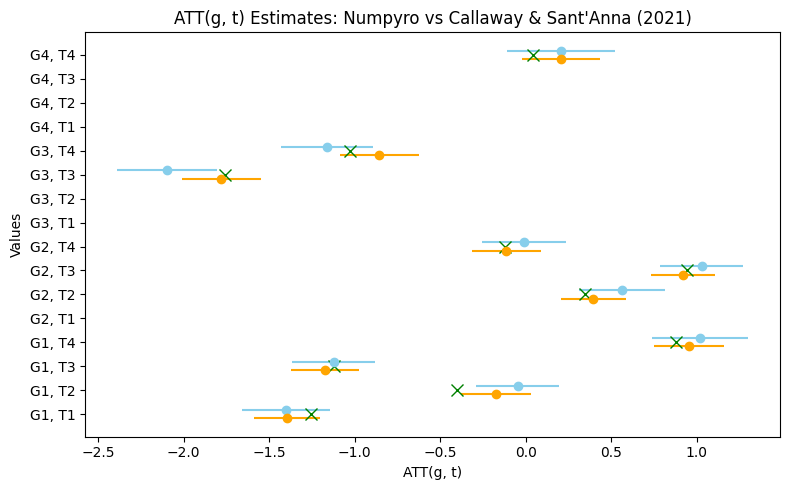

In [9]:
idx_g = np.sort(df_out.index.get_level_values('Group').unique())
idx_t = np.sort(df_out.index.get_level_values('Time').unique())

# Setup numerical X positions and bar width
x = np.arange(df_out.shape[0])  # Numerical indices [0, 1, 2, 3]
width = 0.35  # Width of each bar

categories = [f"G{g}, T{t}" for g in idx_g for t in idx_t]
x = np.arange(len(categories))  # Numerical indices for the categories

fig, ax = plt.subplots(figsize=(8, 5))

# Plot Group 1 (shifted to the left by width/2)
i=0
for g in idx_g:
    for t in idx_t:
        
        # Exclude for plotting cases where t < g, as ATT(g, t) is not defined for those cases
        if t>=g:
            ax.errorbar(
                df_out.loc[(g, t), 'ATT(g, t)'] ,
                x[i] + width / 2,
                xerr=1.96*df_out.loc[(g, t), 'Std. Error'],
                fmt='o',
                color="skyblue",
            )
            ax.errorbar(
                df_out.loc[(g, t), 'ATT_mcmc_mean'] ,
                x[i] - width / 2,
                xerr=1.96*df_out.loc[(g, t), 'ATT_mcmc_std'],
                fmt='o',
                color="orange",
            )
            # Add a true value marker for the ATT(g, t) from the DGP
            ax.plot(
                df_out.loc[(g, t), 'true_ATT'],
                x[i],
                marker='x',
                color='green',
                markersize=8,
                label='True ATT' if i == 0 else "",  # Only add label for the first point
            )
            
        i+=1

# Map the numerical X indices back to your String Categories
ax.set_yticks(x)
ax.set_yticklabels(categories)

ax.set_ylabel("Values")
ax.set_title("ATT(g, t) Estimates: Numpyro vs Callaway & Sant'Anna (2021)")
ax.set_xlabel("ATT(g, t)")
# ax.legend()

plt.tight_layout()
plt.show()

## Part B: Application to real data

Use the data from the Callaway and Sant’Anna (2021) on the effect of states increasing their minimum wages on county-level teen employment rates

In [10]:
# Load data
data_wage = pd.read_csv("https://raw.githubusercontent.com/d2cml-ai/csdid/function-aggte/data/mpdta.csv")

Run the Callaway and Sant’Anna (2021) DiD estimator using the csdid package

In [11]:
out = ATTgt(yname = "lemp",
              gname = "first.treat",
              idname = "countyreal",
              tname = "year",
              xformla = f"lemp~1",
              data = data_wage,
              ).fit(est_method = 'dr')
df_out = out.summ_attgt().summary2
df_out

,Group,Time,"ATT(g, t)",Post,Std. Error,[95% Pointwise,Conf. Band],
0,2004,2004,-0.0105,1,0.0245,-0.0777,0.0566,
1,2004,2005,-0.0704,1,0.0313,-0.1562,0.0153,
2,2004,2006,-0.1373,1,0.0409,-0.2492,-0.0253,*
3,2004,2007,-0.1008,1,0.0332,-0.1915,-0.0101,*
4,2006,2004,0.0065,0,0.0241,-0.0595,0.0726,
5,2006,2005,-0.0028,0,0.0199,-0.0572,0.0517,
6,2006,2006,-0.0046,1,0.0172,-0.0516,0.0424,
7,2006,2007,-0.0412,1,0.0192,-0.0937,0.0113,
8,2007,2004,0.0305,0,0.0154,-0.0115,0.0726,
9,2007,2005,-0.0027,0,0.0172,-0.0499,0.0444,


Estimate the model using NumPyro and compare with the csdid results

In [12]:
map_year_idx = {year: idx for idx, year in enumerate(sorted(data_wage['year'].unique()))}
data_wage['year_idx'] = data_wage['year'].map(map_year_idx)
data_wage['first.treat_idx'] = data_wage['first.treat'].map(map_year_idx)
data_wage

,year,countyreal,lpop,lemp,first.treat,treat,year_idx,first.treat_idx
0,2003,8001,5.896761,8.461469,2007,1,0,4.0
1,2004,8001,5.896761,8.336870,2007,1,1,4.0
2,2005,8001,5.896761,8.340217,2007,1,2,4.0
3,2006,8001,5.896761,8.378161,2007,1,3,4.0
4,2007,8001,5.896761,8.487352,2007,1,4,4.0
...,...,...,...,...,...,...,...,...
2495,2003,55137,3.142168,5.955837,2006,1,0,3.0
2496,2004,55137,3.142168,5.924256,2006,1,1,3.0
2497,2005,55137,3.142168,5.942799,2006,1,2,3.0
2498,2006,55137,3.142168,5.937536,2006,1,3,3.0


In [13]:
# Extent the data frame with additional columns for year index, first treatment index, and county index

first_year = data_wage['year'].min()
# Create unique mapping between years and year_idx
map_year_idx = {year: idx for idx, year in enumerate(sorted(data_wage['year'].unique()))}
data_wage['year_idx'] = data_wage['year'].map(map_year_idx)
# Create first_treat_idx
# data_wage['first.treat_idx2'] = data_wage['first.treat'].map({g: idx for idx, g in enumerate(sorted(data_wage['first.treat'].unique()))})
data_wage['first.treat_idx'] = data_wage['first.treat'].map(map_year_idx)
unique_counties = data_wage['countyreal'].unique()
county_mapping = {county: idx for idx, county in enumerate(unique_counties)}
data_wage['countyreal_idx'] = data_wage['countyreal'].map(county_mapping)
data_wage['is_treated'] = (data_wage['first.treat'] <= data_wage['year']).astype(int)

data_wage.head()

,year,countyreal,lpop,lemp,first.treat,treat,year_idx,first.treat_idx,countyreal_idx,is_treated
0,2003,8001,5.896761,8.461469,2007,1,0,4.0,0,0
1,2004,8001,5.896761,8.336870,2007,1,1,4.0,0,0
2,2005,8001,5.896761,8.340217,2007,1,2,4.0,0,0
3,2006,8001,5.896761,8.378161,2007,1,3,4.0,0,0
4,2007,8001,5.896761,8.487352,2007,1,4,4.0,0,1


In [14]:
num_t = data_wage['year'].nunique()
num_n = data_wage['countyreal'].nunique()

# Convert the relevant columns to JAX arrays
D = jnp.array(data_wage['is_treated'], dtype=jnp.int32)
D_first = jnp.array(data_wage['first.treat_idx'], dtype=jnp.int32)
T = jnp.array(data_wage['year_idx'], dtype=jnp.int32)
I = jnp.array(data_wage['countyreal_idx'], dtype=jnp.int32)
Y = jnp.array(data_wage['lemp'], dtype=jnp.float32)

# Estimate Numpyro model using MCMC
rng_key, rng_key_ = random.split(rng_key)
kernel = NUTS(dgp_CallawaySantAnna_did)
mcmc = MCMC(kernel, num_samples=500, num_warmup=500, num_chains=1)
mcmc.run(rng_key_, num_n=num_n, num_t=num_t, D=D, D_first=D_first, T=T, I=I, Y=Y)
post_samples = mcmc.get_samples()

azMCMC = az.from_numpyro(mcmc)

/usr/local/lib/python3.12/dist-packages/pandas/core/series.py:899: RuntimeWarning: invalid value encountered in cast
  arr = np.asarray(values, dtype=dtype)
sample: 100%|██████████| 1000/1000 [00:12<00:00, 78.29it/s, 31 steps of size 1.61e-01. acc. prob=0.88] 


In [15]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
  ATT[0,0]     -0.00      0.04     -0.00     -0.07      0.06    438.11      1.00
  ATT[0,1]     -0.06      0.04     -0.06     -0.12      0.03    486.59      1.00
  ATT[0,2]     -0.12      0.04     -0.12     -0.19     -0.05    321.20      1.00
  ATT[0,3]     -0.09      0.04     -0.09     -0.16     -0.02    384.35      1.00
  ATT[1,0]     -0.04      0.98     -0.06     -1.70      1.52    810.88      1.00
  ATT[1,1]      0.02      1.03      0.01     -1.73      1.64    890.69      1.00
  ATT[1,2]     -0.05      0.98     -0.02     -1.57      1.60   1581.76      1.00
  ATT[1,3]      0.01      1.03      0.02     -1.49      1.94   3280.69      1.00
  ATT[2,0]      0.01      1.01      0.02     -1.53      1.67   1173.15      1.00
  ATT[2,1]     -0.05      1.11     -0.04     -1.86      1.57   1267.05      1.00
  ATT[2,2]      0.01      0.03      0.01     -0.03      0.05    517.62      1.00
  ATT[2,3]     -0.03      0

In [16]:
# Print mcmc summary, but only for ATT, excluding alpha, phi, and y_sigma
az.summary(azMCMC, var_names=['ATT'], round_to=2)


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
"ATT[0, 0]",-0.00,0.04,-0.07,0.06,428.23,415.63,NaN,0.00,0.00
"ATT[0, 1]",-0.06,0.04,-0.14,0.01,498.97,393.58,NaN,0.00,0.00
"ATT[0, 2]",-0.12,0.04,-0.19,-0.05,316.94,301.02,NaN,0.00,0.00
"ATT[0, 3]",-0.09,0.04,-0.16,-0.02,393.47,383.24,NaN,0.00,0.00
"ATT[1, 0]",-0.04,0.98,-1.64,1.52,872.26,377.92,NaN,0.03,0.02
"ATT[1, 1]",0.02,1.03,-1.64,1.64,875.31,262.01,NaN,0.04,0.03
"ATT[1, 2]",-0.05,0.98,-1.61,1.49,1349.49,353.42,NaN,0.03,0.02
"ATT[1, 3]",0.01,1.03,-1.67,1.80,1349.49,221.73,NaN,0.03,0.02
"ATT[2, 0]",0.01,1.01,-1.52,1.63,1119.22,220.86,NaN,0.03,0.02
"ATT[2, 1]",-0.05,1.11,-1.74,1.57,1310.50,286.88,NaN,0.03,0.02


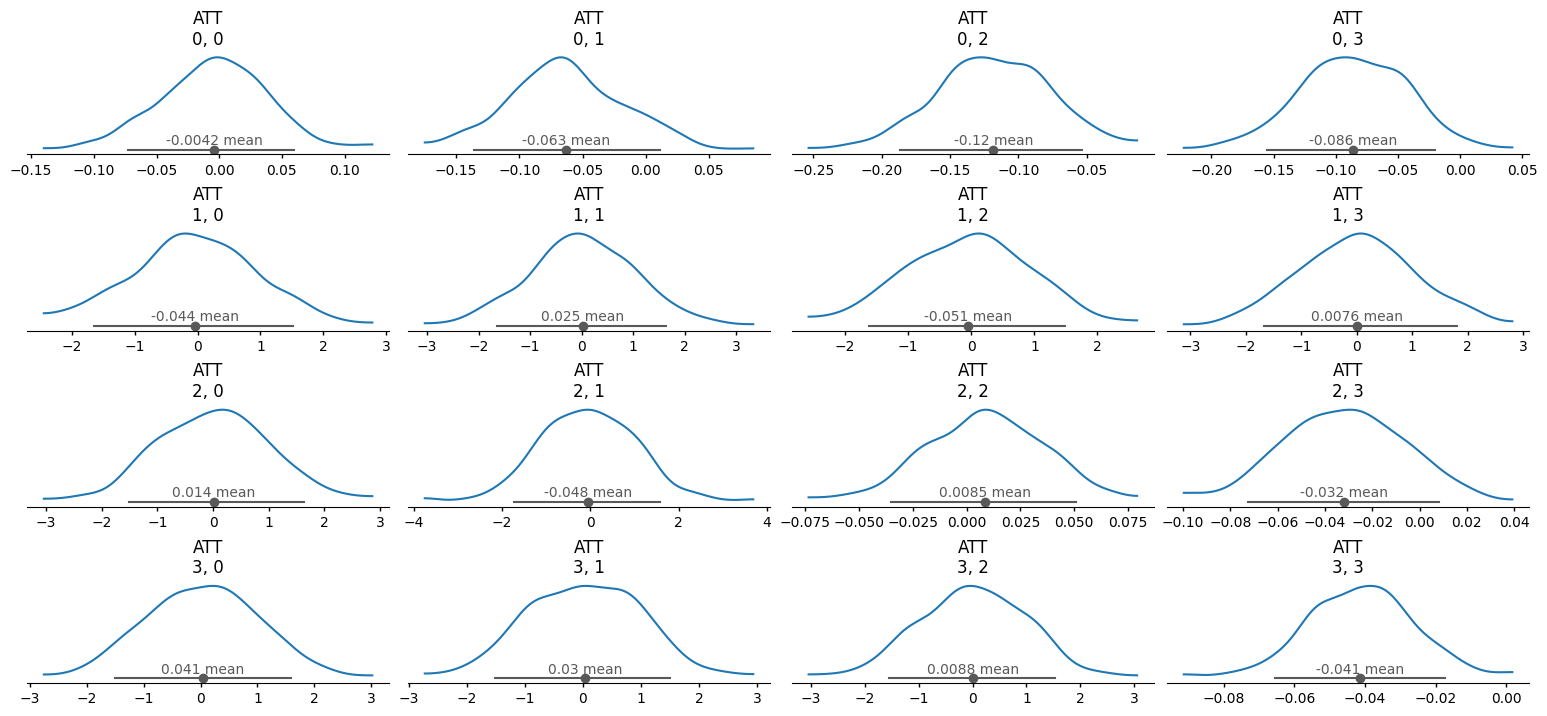

In [17]:
# Plot results using arviz
plt.rcParams['figure.constrained_layout.use'] = True
az.plot_dist(azMCMC,
             kind="kde",
            var_names=["ATT"],
            );

In [18]:
df_out.set_index(['Group', 'Time'], inplace=True)

In [19]:
# Calculate the mean of the ATT samples across all MCMC samples
ATT_mcmc_mean = jnp.mean(post_samples['ATT'], axis=0)
ATT_mcmc_std = jnp.std(post_samples['ATT'], axis=0)

# Add to df_out
df_mcmc_mean = (pd.DataFrame(ATT_mcmc_mean, index=[g+first_year+1 for g in range(num_t-1)], 
                       columns=[t+first_year+1 for t in range(num_t-1)])
            .stack().to_frame(name='ATT_mcmc_mean')
            .reset_index().rename(columns={'level_0': 'Group', 'level_1': 'Time'})).set_index(['Group', 'Time'])
df_std_mean = (pd.DataFrame(ATT_mcmc_std, index=[g+first_year+1 for g in range(num_t-1)], 
                       columns=[t+first_year+1 for t in range(num_t-1)])
            .stack().to_frame(name='ATT_mcmc_std')
            .reset_index().rename(columns={'level_0': 'Group', 'level_1': 'Time'})).set_index(['Group', 'Time'])
df_out = df_out.join(df_mcmc_mean, how='right')
df_out = df_out.join(df_std_mean, how='right')
df_out

ATT(g, t)  Post  Std. Error  [95% Pointwise  Conf. Band]       \
Group Time                                                                  
2004  2004    -0.0105   1.0      0.0245         -0.0777       0.0566        
      2005    -0.0704   1.0      0.0313         -0.1562       0.0153        
      2006    -0.1373   1.0      0.0409         -0.2492      -0.0253    *   
      2007    -0.1008   1.0      0.0332         -0.1915      -0.0101    *   
2005  2004        NaN   NaN         NaN             NaN          NaN  NaN   
      2005        NaN   NaN         NaN             NaN          NaN  NaN   
      2006        NaN   NaN         NaN             NaN          NaN  NaN   
      2007        NaN   NaN         NaN             NaN          NaN  NaN   
2006  2004     0.0065   0.0      0.0241         -0.0595       0.0726        
      2005    -0.0028   0.0      0.0199         -0.0572       0.0517        
      2006    -0.0046   1.0      0.0172         -0.0516       0.0424        
      2007    -0.0412   1.0      0.0192         -0.0937       0.0113        
2007  2004     0.0305   0.0      0.0154         -0.0115       0.0726        
      2005    -0.0027   0.0      0.0172         -0.0499       0.0444        
      2006    -0.0311   0.0      0.0172         -0.0782       0.0160        
      2007    -0.0261   1.0      0.0172         -0.0731       0.0210        

            ATT_mcmc_mean  ATT_mcmc_std  
Group Time                               
2004  2004      -0.004155      0.042406  
      2005      -0.062897      0.044286  
      2006      -0.118387      0.041542  
      2007      -0.086018      0.042826  
2005  2004      -0.043903      0.980654  
      2005       0.024840      1.030749  
      2006      -0.051013      0.979586  
      2007       0.007613      1.032678  
2006  2004       0.013671      1.013533  
      2005      -0.047805      1.109963  
      2006       0.008524      0.027414  
      2007      -0.031805      0.025328  
2007  2004       0.041452      0.991390  
      2005       0.030003      0.986795  
      2006       0.008821      1.011977  
      2007      -0.041275      0.015289

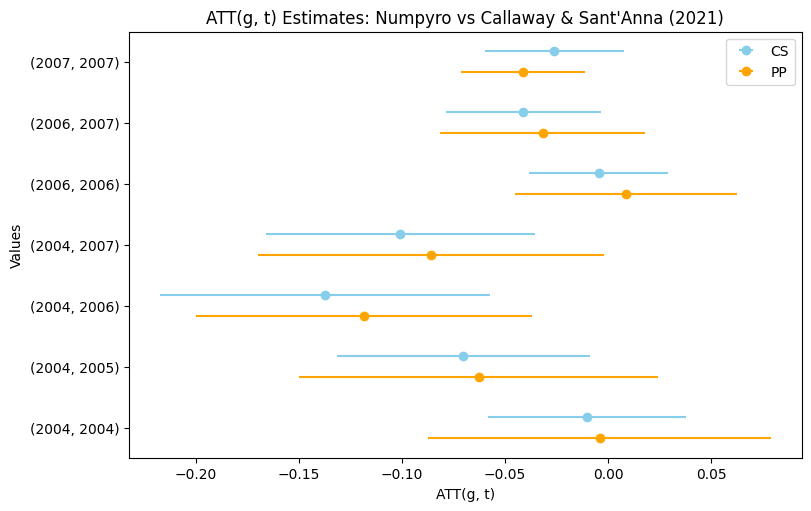

In [20]:
# Filter only cases where ATT(g, t) is not NaN and where Time >= Group
# Note it is also interesting to plot the cases where Time < Group, because the PP
# model indicates, by the large uncertainty, that those cases are not identified 
plot_only_cases_where_ATT_is_defined = True
if plot_only_cases_where_ATT_is_defined:
    df_out_not_nan = df_out[((~df_out['ATT(g, t)'].isna())) & (df_out.index.get_level_values('Time')>=df_out.index.get_level_values('Group'))]
else:
    # Use this to plot only the cases where ATT(g, t) is defined and not NaN
    df_out_not_nan = df_out[((~df_out['ATT(g, t)'].isna()))]

# Setup numerical X positions and bar width
x = np.arange(df_out_not_nan.shape[0])  # Numerical indices [0, 1, 2, 3]
width = 0.35  # Width of each bar

# categories = [f"G{g}, T{t}" for g in idx_g for t in idx_t]
categories = [(idx[0], idx[1]) for idx in df_out_not_nan.index.values]
x = np.arange(len(categories))  # Numerical indices for the categories

fig, ax = plt.subplots(figsize=(8, 5))

i=0
for idx in categories:
        
        g, t = idx
        # Check if the value is not NaN before plotting
        ax.errorbar(
            df_out.loc[(g, t), 'ATT(g, t)'] ,
            x[i] + width / 2,
            xerr=1.96*df_out.loc[(g, t), 'Std. Error'],
            fmt='o',
            color="skyblue",
            label="CS" if i == 0 else ""
        )
        ax.errorbar(
            df_out.loc[(g, t), 'ATT_mcmc_mean'] ,
            x[i] - width / 2,
            xerr=1.96*df_out.loc[(g, t), 'ATT_mcmc_std'],
            fmt='o',
            color="orange",
            label="PP" if i == 0 else ""
        )

           
        i+=1

# Map the numerical X indices back to your String Categories
ax.set_yticks(x)
ax.set_yticklabels(categories)

ax.set_ylabel("Values")
ax.set_title("ATT(g, t) Estimates: Numpyro vs Callaway & Sant'Anna (2021)")
ax.set_xlabel("ATT(g, t)")
ax.legend()

# plt.tight_layout()
plt.show()

## Part C: Extend the model to include covariates

In [21]:
num_t = 5 # number of time periods
num_n = 1000 # number of individuals
num_k = 2 # number of time-invariant covariates

# Generate a (NxK,) dimensional matrix of time-invariant covariates X
X = np.random.normal(size=(num_n, num_k))+1
X_flat = jnp.repeat(X, num_t, axis=0)
assert X_flat.shape == (num_n*num_t, num_k), f"X_flat shape is {X_flat.shape}, expected {(num_n*num_t, num_k)}"

W = np.random.choice([0, 1, 2], size=(num_n, ))
W_flat = jnp.repeat(W, num_t, axis=0)

# Define a (NxT,) dimensional treatment assignment vector D, 
# first N rows are for period t=0, all or none treated
# remaining (num_t-1xN) rows are for period t=1,...,num_t, with a random assignment of treatment
D_t = np.random.binomial(1, 0.2, size=(num_n,num_t-1))
D = jnp.concatenate([jnp.zeros((num_n, 1)), D_t], axis=1)

# Take the cumsum such that treatment is irreversible, and clip at 1
D = jnp.clip(jnp.cumsum(D, axis=1), 0, 1)
D = jnp.array(D, dtype=jnp.int32)
D_flat = D.flatten()
print("Shape of the flattened treatment assignment matrix D:", D_flat.shape)

# Create an (NxT,) index for the individuals
I = jnp.repeat(np.arange(num_n), num_t) 
I = jnp.array(I, dtype=jnp.int32) 
print("Shape of the individual index I:", I.shape)

# Create an (NxT,) index for the time periods
T = jnp.tile(jnp.arange(num_t), num_n)
T = jnp.array(T, dtype=jnp.int32)
print("Shape of the time index T:", T.shape)

# Determine the first period of treatment for each individual
D_first = jnp.argmax(D, axis=1)  # This will give the index of the first occurrence of treatment for each individual
D_first_flat = jnp.repeat(D_first, num_t)  # Repeat for each time period for each individual
D_first_flat = jnp.array(D_first_flat, dtype=jnp.int32)
print("Shape of the flattened first treatment period index D_first_flat:", D_first_flat.shape)

data = pd.DataFrame({
    'individual': I,
    'time': T,
    'treatment': D_flat,
    'first_treatment': D_first_flat
})

# Get list with unique groups and unique time periods
unique_groups = np.sort(data['first_treatment'].unique())
unique_times = np.sort(data['time'].unique())

# Add the covariates to the DataFrame
for k in range(num_k):
    data[f'X_{k}'] = X_flat[:, k]

data['W'] = W_flat

data.head(20)  # Show the first 10 rows of the DataFrame

Shape of the flattened treatment assignment matrix D: (5000,)
Shape of the individual index I: (5000,)
Shape of the time index T: (5000,)
Shape of the flattened first treatment period index D_first_flat: (5000,)


,individual,time,treatment,first_treatment,X_0,X_1,W
0,0,0,0,0,0.427436,0.204290,0
1,0,1,0,0,0.427436,0.204290,0
2,0,2,0,0,0.427436,0.204290,0
3,0,3,0,0,0.427436,0.204290,0
4,0,4,0,0,0.427436,0.204290,0
5,1,0,0,3,2.903416,1.451622,2
6,1,1,0,3,2.903416,1.451622,2
7,1,2,0,3,2.903416,1.451622,2
8,1,3,1,3,2.903416,1.451622,2
9,1,4,1,3,2.903416,1.451622,2


### Data-generating process

Extend the simple DGP from above to include covariates \(X_i\) and \(W_i\) that affect the outcome and the treatment effect, respectively. The outcome model is then given by:

$Y_{it} \sim \mathcal{N}(\mu_{it}, \sigma_Y^2)$

$\mu_{it}=\alpha_i+\phi_t+X_i\beta^X +D_{it}\,(ATT(G_i,t)\,+\,W_i \beta^W) $ 

With priors:

$\alpha_i, \phi_t \sim\mathcal{N}(0,1)$

<!-- $\phi_t\sim\mathcal{N}(0,1)$ -->

$ATT(g,t)\sim\mathcal{N}(0,1)$

$\sigma_Y\sim\operatorname{HalfNormal}(1)$

$\beta^X\sim\mathcal{N}(0, I_K),$

$\beta^W\sim\mathcal{N}(0, I_R).$




In [22]:
def dgp_CallawaySantAnna_did_covariates(num_n, num_t, D, D_first, T, I, X=None, W=None, Y=None):
    
    # Define the group time average treatment effect (ATT(g,t)) for each group and time period
    ATT = numpyro.sample("ATT", dist.Normal(0.0, 1).expand([num_t-1, num_t-1]))
    
    # Add a vector of zeros for the untreated group (g=0) to the ATT matrix
    ATT = jnp.concatenate([jnp.zeros((1, num_t-1)), ATT], axis=0)
    # Add a vector of zeros for the first time period (t=0) to the ATT matrix
    ATT = jnp.concatenate([jnp.zeros((num_t, 1)), ATT], axis=1)
    
    # Define prior of individual effects
    alpha = numpyro.sample("alpha", dist.Normal(0.0, 1.0).expand([num_n]))
    # Define prior of temporal effects
    phi = numpyro.sample("phi", dist.Normal(0.0, 1.0).expand([num_t]))
    
    # Define deterministics part of the outcome variable
    y_mean = alpha[I] + phi[T]
    # Add the treatment effect to the mean of the outcome variable
    if W is not None:
        # Treatment effect is a function of the covariates W, which are time-invariant covariates
        # Define a prior for the 
        beta_W = numpyro.sample("beta_W", dist.Normal(0.0, 1.0).expand([W.shape[1]]))
        mean_ATT = W @ beta_W
        
        y_mean += D*(ATT[D_first, T]+mean_ATT)
    else:
        # If no covariates are available, use the standard treatment effect
        y_mean += D*ATT[D_first, T]
    
    if X is not None:
        # If time-invariant covariates X are available, include them in the model
        # Define regression coefficients for the covariates
        beta_X = numpyro.sample("beta_X", dist.Normal(0.0, 1.0).expand([X.shape[1]]))
        y_mean += X @ beta_X

    # Define prior of the standard deviation of the outcome variable
    y_sigma = numpyro.sample("y_sigma", dist.HalfNormal(1.0))
    
    # Define the outcome variable
    numpyro.sample("Y", dist.Normal(y_mean, y_sigma), obs=Y)

In [23]:
model_fn = dgp_CallawaySantAnna_did_covariates
    
# Sample for the DGP
rng_key,_ = random.split(rng_key)
prior_predictive = Predictive(model_fn,num_samples=1,)
prior_samples = prior_predictive(rng_key, num_n=num_n, num_t=num_t, D=D_flat, 
                                 D_first=D_first_flat, T=T, I=I, X=X_flat,W=W_flat[:, None])
prior_samples.keys()

Y_syn = prior_samples["Y"][0]
print("Shape of the synthetic outcome variable Y:", Y_syn.shape)
ATT_true = prior_samples["ATT"][0]
print("Shape of the true treatment effect ATT:", ATT_true.shape)

beta_X_true = prior_samples["beta_X"][0]
print("True regression coefficients beta_X:", beta_X_true)

beta_W_true = prior_samples["beta_W"][0]
print("True regression coefficients beta_W:", beta_W_true)

# Add the synthetic outcome variable to the data DataFrame
data['Y'] = Y_syn

Shape of the synthetic outcome variable Y: (5000,)
Shape of the true treatment effect ATT: (4, 4)
True regression coefficients beta_X: [-0.20038295 -0.11444677]
True regression coefficients beta_W: [-0.74277]


In [24]:
data

,individual,time,treatment,first_treatment,X_0,X_1,W,Y
0,0,0,0,0,0.427436,0.204290,0,-0.878725
1,0,1,0,0,0.427436,0.204290,0,-1.285589
2,0,2,0,0,0.427436,0.204290,0,-0.744791
3,0,3,0,0,0.427436,0.204290,0,0.039715
4,0,4,0,0,0.427436,0.204290,0,-1.152865
...,...,...,...,...,...,...,...,...
4995,999,0,0,3,-1.434721,1.421818,1,-1.284764
4996,999,1,0,3,-1.434721,1.421818,1,-2.291348
4997,999,2,0,3,-1.434721,1.421818,1,-1.090122
4998,999,3,1,3,-1.434721,1.421818,1,-2.327351


In [25]:
out = ATTgt(yname = "Y",
              gname = "first_treatment",
              idname = "individual",
              tname = "time",
              xformla = f"Y~1+X_0+X_1+W",
              data = data,
              ).fit(est_method = 'dr')
df_out = out.summ_attgt().summary2

df_out.set_index(['Group', 'Time'], inplace=True)

df_out

ATT(g, t)  Post  Std. Error  [95% Pointwise  Conf. Band]   
Group Time                                                             
1     1       -1.7137     1      0.0602         -1.8874      -1.5399  *
      2        0.9028     1      0.0569          0.7385       1.0670  *
      3       -0.7446     1      0.0574         -0.9103      -0.5789  *
      4       -1.5267     1      0.0542         -1.6833      -1.3702  *
2     1       -0.0448     0      0.0399         -0.1600       0.0703   
      2       -2.5272     1      0.0623         -2.7070      -2.3475  *
      3       -1.5559     1      0.0596         -1.7280      -1.3837  *
      4       -0.5170     1      0.0659         -0.7073      -0.3268  *
3     1        0.0050     0      0.0459         -0.1274       0.1374   
      2        0.0823     0      0.0486         -0.0579       0.2226   
      3       -0.7075     1      0.0672         -0.9014      -0.5137  *
      4       -0.1317     1      0.0617         -0.3097       0.0463   
4     1       -0.0667     0      0.0542         -0.2231       0.0896   
      2        0.1406     0      0.0462          0.0072       0.2740  *
      3       -0.0982     0      0.0563         -0.2607       0.0642   
      4        0.2720     1      0.0951         -0.0025       0.5465

In [26]:
rng_key, rng_key_ = random.split(rng_key)
kernel = NUTS(dgp_CallawaySantAnna_did_covariates)
mcmc = MCMC(kernel, num_samples=500, num_warmup=500, num_chains=1)
mcmc.run(rng_key_, num_n=num_n, num_t=num_t, D=data['treatment'].values, D_first=data['first_treatment'].values, T=data['time'].values, 
         I=data['individual'].values, Y=data['Y'].values, 
         X=data[['X_0', 'X_1']].values,
         W=data['W'].values[:, None]
         )
post_samples = mcmc.get_samples()
azMCMC = az.from_numpyro(mcmc)

sample: 100%|██████████| 1000/1000 [00:21<00:00, 46.37it/s, 31 steps of size 1.03e-01. acc. prob=0.92]


In [27]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
  ATT[0,0]     -0.97      0.04     -0.97     -1.03     -0.90    104.12      1.00
  ATT[0,1]      1.61      0.04      1.61      1.54      1.66    104.50      1.00
  ATT[0,2]     -0.02      0.04     -0.02     -0.08      0.04     92.90      1.00
  ATT[0,3]     -0.80      0.04     -0.80     -0.87     -0.74    105.83      1.00
  ATT[1,0]     -0.03      1.03     -0.03     -1.50      1.77    490.92      1.00
  ATT[1,1]     -1.76      0.04     -1.76     -1.82     -1.69    220.21      1.00
  ATT[1,2]     -0.76      0.04     -0.76     -0.82     -0.71    184.93      1.00
  ATT[1,3]      0.28      0.04      0.28      0.21      0.34    192.25      1.00
  ATT[2,0]     -0.04      0.99     -0.05     -1.49      1.61    389.96      1.00
  ATT[2,1]     -0.01      0.96      0.03     -1.73      1.48    466.50      1.00
  ATT[2,2]      0.03      0.03      0.03     -0.02      0.09    219.06      1.00
  ATT[2,3]      0.61      0

In [28]:
# Derive true ATT for the three different categories of the categorical covariate (0, 1, 2)
ATT_W_low_true = beta_W_true[0] * 0 + ATT_true
ATT_W_medium_true = beta_W_true[0] * 1 + ATT_true
ATT_W_high_true = beta_W_true[0] * 2 + ATT_true

df_out["ATT_W_low_true"] = ATT_W_low_true.flatten()
df_out["ATT_W_medium_true"] = ATT_W_medium_true.flatten()
df_out["ATT_W_high_true"] = ATT_W_high_true.flatten()



In [29]:
cat_names = ["low", "medium", "high"]
# Derive the mean and standard deviation of the ATT samples for each category of the categorical covariate (0, 1, 2)
ATT_W_low = 0*post_samples['beta_W'][:,0]
ATT_W_medium = 1*post_samples['beta_W'][:,0]
ATT_W_high = 2*post_samples['beta_W'][:,0]
ATT_W_low_mean = np.mean((ATT_W_low[:,None,None]+post_samples['ATT']),axis=0)
ATT_W_medium_mean = np.mean((ATT_W_medium[:,None,None]+post_samples['ATT']),axis=0)
ATT_W_high_mean = np.mean((ATT_W_high[:,None,None]+post_samples['ATT']),axis=0)

ATT_W_low_std = np.std((ATT_W_low[:,None,None]+post_samples['ATT']),axis=0)
ATT_W_medium_std = np.std((ATT_W_medium[:,None,None]+post_samples['ATT']),axis=0)
ATT_W_high_std = np.std((ATT_W_high[:,None,None]+post_samples['ATT']),axis=0)
                        
df_out['ATT_W_low_mean'] = ATT_W_low_mean.flatten()
df_out['ATT_W_medium_mean'] = ATT_W_medium_mean.flatten()
df_out['ATT_W_high_mean'] = ATT_W_high_mean.flatten()
df_out['ATT_W_low_std'] = ATT_W_low_std.flatten()
df_out['ATT_W_medium_std'] = ATT_W_medium_std.flatten()
df_out['ATT_W_high_std'] = ATT_W_high_std.flatten()


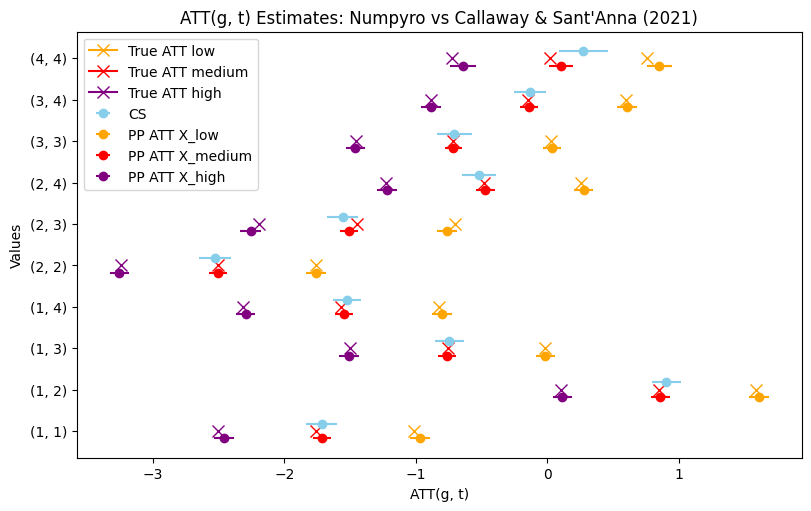

In [30]:
# Filter only cases where ATT(g, t) is not NaN and where Time >= Group
# Note it is also interesting to plot the cases where Time < Group, because the PP
# model indicates, by the large uncertainty, that those cases are not identified 
plot_only_cases_where_ATT_is_defined = True
if plot_only_cases_where_ATT_is_defined:
    df_out_not_nan = df_out[((~df_out['ATT(g, t)'].isna())) & (df_out.index.get_level_values('Time')>=df_out.index.get_level_values('Group'))]
else:
    # Use this to plot only the cases where ATT(g, t) is defined and not NaN
    df_out_not_nan = df_out[((~df_out['ATT(g, t)'].isna()))]

# Setup numerical X positions and bar width
x = np.arange(df_out_not_nan.shape[0])  # Numerical indices [0, 1, 2, 3]
width = 0.35  # Width of each bar

# categories = [f"G{g}, T{t}" for g in idx_g for t in idx_t]
categories = [(idx[0], idx[1]) for idx in df_out_not_nan.index.values]
x = np.arange(len(categories))  # Numerical indices for the categories

fig, ax = plt.subplots(figsize=(8, 5))

i=0
for idx in categories:
        
        g, t = idx
        # Check if the value is not NaN before plotting
        ax.errorbar(
            df_out.loc[(g, t), 'ATT(g, t)'] ,
            x[i] + width / 2,
            xerr=1.96*df_out.loc[(g, t), 'Std. Error'],
            fmt='o',
            color="skyblue",
            label="CS" if i == 0 else ""
        )
        colors = ["orange", "red", "purple"]
        i_offset = 0
        for cat in ['low', 'medium', 'high']:
            ax.errorbar(
                df_out.loc[(g, t), f'ATT_W_{cat}_mean'],
                # x[i] - width / 2- i_offset * 0.3,
                x[i] - width / 2,
                xerr=1.96*df_out.loc[(g, t), f'ATT_W_{cat}_std'],  
                fmt='o',
                color=colors[i_offset],
                label=f"PP ATT X_{cat}" if i == 0 else ""
            )
            
            # Add a true value marker for the ATT(g, t) from the DGP
            ax.plot(
                df_out.loc[(g, t), f'ATT_W_{cat}_true'],
                x[i],
                marker='x',
                color=colors[i_offset],
                markersize=8,
                label=f'True ATT {cat}' if i == 0 else "",  # Only add label for the first point
            )
            i_offset+=1
  
        i+=1

# Map the numerical X indices back to your String Categories
ax.set_yticks(x)
ax.set_yticklabels(categories)

ax.set_ylabel("Values")
ax.set_title("ATT(g, t) Estimates: Numpyro vs Callaway & Sant'Anna (2021)")
ax.set_xlabel("ATT(g, t)")
ax.legend()

# plt.tight_layout()
plt.show()

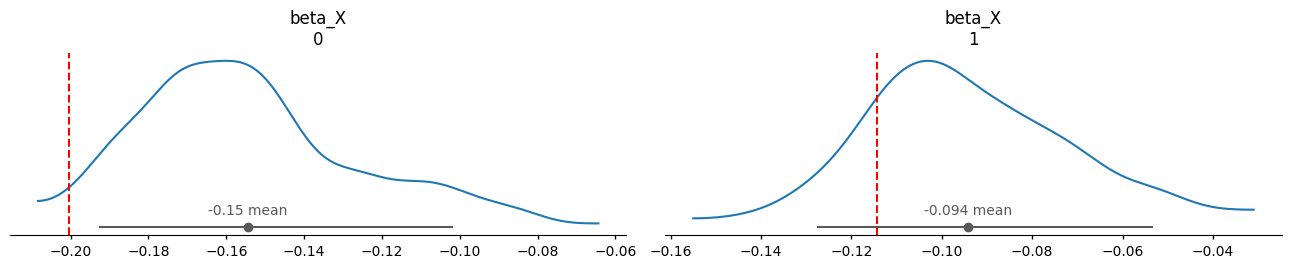

In [31]:
# Plot results using arviz
plt.rcParams['figure.constrained_layout.use'] = True
pc  = az.plot_dist(azMCMC,
             kind="kde",
            var_names=["beta_X"],
            );
# Add beta_true to the plot
pc.viz
for i in range(len(beta_X_true)): 
    pc.get_viz("plot").values[i].axvline(beta_X_true[i], ymin=0, ymax= 1, color='red', linestyle='--', label='True beta_0')

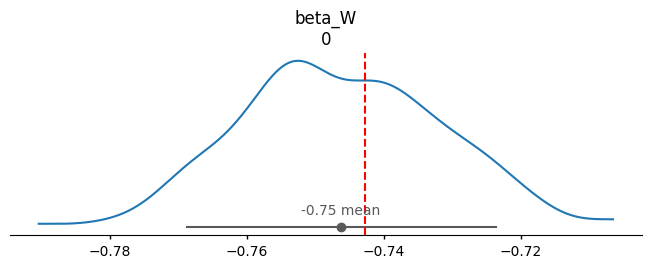

In [32]:
# Plot results using arviz
plt.rcParams['figure.constrained_layout.use'] = True
pc  = az.plot_dist(azMCMC,
             kind="kde",
            var_names=["beta_W"],
            );
# Add beta_true to the plot
# pc.viz
pc.get_viz("plot").axvline(beta_W_true, ymin=0, ymax= 1, color='red', linestyle='--')

### Estimate with real data

*Note: In opposite to the example above the analysis is performed on a standardized scales of the outcome variable (lemp) and the covariate (lpop) to make the estimation more stable. The standardization is done by subtracting the mean and dividing by the standard deviation of the variable.*

In [33]:
# Load data
data_wage = pd.read_csv("https://raw.githubusercontent.com/d2cml-ai/csdid/function-aggte/data/mpdta.csv")

first_year = data_wage['year'].min()
# Create unique mapping between years and year_idx
map_year_idx = {year: idx for idx, year in enumerate(sorted(data_wage['year'].unique()))}
data_wage['year_idx'] = data_wage['year'].map(map_year_idx)
# Create first_treat_idx
data_wage['first.treat_idx'] = data_wage['first.treat'].map(map_year_idx)

unique_counties = data_wage['countyreal'].unique()
county_mapping = {county: idx for idx, county in enumerate(unique_counties)}
data_wage['countyreal_idx'] = data_wage['countyreal'].map(county_mapping)

data_wage['is_treated'] = (data_wage['first.treat'] <= data_wage['year']).astype(int)

# Standardize lpop and lemp
data_wage['lpop_std'] = (data_wage['lpop'] - data_wage['lpop'].mean()) / data_wage['lpop'].std()
data_wage['lemp_std'] = (data_wage['lemp'] - data_wage['lemp'].mean()) / data_wage['lemp'].std()

# Fill NaN values in 'first.treat_idx' with 0, that value does not matter in the model, because those cases are not treated and will not be used in the ATT(g, t) estimation
data_wage['first.treat_idx'] = data_wage['first.treat_idx'].fillna(0)

data_wage.head()

,year,countyreal,lpop,lemp,first.treat,treat,year_idx,first.treat_idx,countyreal_idx,is_treated,lpop_std,lemp_std
0,2003,8001,5.896761,8.461469,2007,1,0,4.0,0,0,2.016493,1.782202
1,2004,8001,5.896761,8.336870,2007,1,1,4.0,0,0,2.016493,1.699619
2,2005,8001,5.896761,8.340217,2007,1,2,4.0,0,0,2.016493,1.701838
3,2006,8001,5.896761,8.378161,2007,1,3,4.0,0,0,2.016493,1.726986
4,2007,8001,5.896761,8.487352,2007,1,4,4.0,0,1,2.016493,1.799357


In [34]:
num_t = data_wage['year'].nunique()
num_n = data_wage['countyreal'].nunique()

# Convert the relevant columns to JAX arrays
D = jnp.array(data_wage['is_treated'], dtype=jnp.int32)
D_first = jnp.array(data_wage['first.treat_idx'], dtype=jnp.int32)
T = jnp.array(data_wage['year_idx'], dtype=jnp.int32)
I = jnp.array(data_wage['countyreal_idx'], dtype=jnp.int32)
Y = jnp.array(data_wage['lemp_std'], dtype=jnp.float32)
X = jnp.array(data_wage['lpop_std'], dtype=jnp.float32)

In [35]:
# Estimate Numpyro model using MCMC
rng_key, rng_key_ = random.split(rng_key)
kernel = NUTS(dgp_CallawaySantAnna_did_covariates)
mcmc = MCMC(kernel, num_samples=500, num_warmup=500, num_chains=1)
mcmc.run(rng_key_, num_n=num_n, num_t=num_t, D=D, D_first=D_first, 
         T=T, I=I, Y=Y,
         X=X[:, None], 
         W=X[:, None]
         )
post_samples = mcmc.get_samples()

azMCMC = az.from_numpyro(mcmc)

sample: 100%|██████████| 1000/1000 [00:22<00:00, 44.04it/s, 63 steps of size 5.95e-02. acc. prob=0.94]


In [36]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
  ATT[0,0]     -0.02      0.03     -0.02     -0.06      0.03    209.65      1.00
  ATT[0,1]     -0.05      0.03     -0.05     -0.10     -0.01    201.55      1.00
  ATT[0,2]     -0.09      0.03     -0.09     -0.13     -0.04    208.51      1.00
  ATT[0,3]     -0.07      0.03     -0.07     -0.11     -0.02    195.81      1.00
  ATT[1,0]     -0.02      0.96     -0.07     -1.67      1.42    848.13      1.00
  ATT[1,1]     -0.02      0.99      0.01     -1.55      1.64    642.18      1.00
  ATT[1,2]     -0.05      1.06     -0.03     -1.84      1.60   1282.44      1.00
  ATT[1,3]      0.05      1.00      0.08     -1.57      1.54    867.01      1.00
  ATT[2,0]     -0.00      0.92     -0.01     -1.45      1.54   1175.98      1.00
  ATT[2,1]      0.02      0.92      0.06     -1.67      1.26   1072.76      1.00
  ATT[2,2]     -0.00      0.02     -0.00     -0.03      0.03    572.98      1.00
  ATT[2,3]     -0.03      0

Estimate the model using the csdid package 

*Note: Estimation is performed on the standardized scale.*

In [37]:
out = ATTgt(yname = "lemp_std",
              gname = "first.treat",
              idname = "countyreal",
              tname = "year",
              xformla = f"lemp_std~1+lpop_std",
              data = data_wage,
              ).fit(est_method = 'dr')
df_out = out.summ_attgt().summary2
df_out

,Group,Time,"ATT(g, t)",Post,Std. Error,[95% Pointwise,Conf. Band],
0,2004,2004,-0.0096,1,0.0144,-0.0479,0.0286,
1,2004,2005,-0.0507,1,0.0203,-0.1048,0.0035,
2,2004,2006,-0.0931,1,0.0247,-0.1589,-0.0273,*
3,2004,2007,-0.0709,1,0.0229,-0.1318,-0.0099,*
4,2006,2004,-0.0003,0,0.0150,-0.0403,0.0397,
5,2006,2005,-0.0041,0,0.0125,-0.0373,0.0290,
6,2006,2006,0.0006,1,0.0130,-0.0340,0.0353,
7,2006,2007,-0.0274,1,0.0128,-0.0614,0.0066,
8,2007,2004,0.0177,0,0.0094,-0.0072,0.0427,
9,2007,2005,-0.0030,0,0.0101,-0.0298,0.0237,


In [38]:
df_out.set_index(['Group', 'Time'], inplace=True)

In [39]:
cat_names = ["low", "medium", "high"]
# Derive the mean and standard deviation of the ATT samples for each category of the categorical covariate (0, 1, 2)
ATT_W_low = np.percentile(data_wage['lpop_std'], 10) * post_samples['beta_W'][:,0]
ATT_W_medium = np.percentile(data_wage['lpop_std'], 50) * post_samples['beta_W'][:,0]
ATT_W_high = np.percentile(data_wage['lpop_std'], 90) * post_samples['beta_W'][:,0]
ATT_W_low_mean = np.mean((ATT_W_low[:,None,None]+post_samples['ATT']),axis=0)
ATT_W_medium_mean = np.mean((ATT_W_medium[:,None,None]+post_samples['ATT']),axis=0)
ATT_W_high_mean = np.mean((ATT_W_high[:,None,None]+post_samples['ATT']),axis=0)

ATT_W_low_std = np.std((ATT_W_low[:,None,None]+post_samples['ATT']),axis=0)
ATT_W_medium_std = np.std((ATT_W_medium[:,None,None]+post_samples['ATT']),axis=0)
ATT_W_high_std = np.std((ATT_W_high[:,None,None]+post_samples['ATT']),axis=0)
    

for name,arr in [["ATT_W_low_mean",ATT_W_low_mean],["ATT_W_medium_mean",ATT_W_medium_mean],["ATT_W_high_mean",ATT_W_high_mean],
                 ["ATT_W_low_std",ATT_W_low_std],["ATT_W_medium_std",ATT_W_medium_std],["ATT_W_high_std",ATT_W_high_std]]:
    aa = (pd.DataFrame(arr, index=[g+first_year+1 for g in range(num_t-1)], 
                        columns=[t+first_year+1 for t in range(num_t-1)])
                .stack().to_frame(name=name)
                .reset_index().rename(columns={'level_0': 'Group', 'level_1': 'Time'})).set_index(['Group', 'Time'])
    df_out = df_out.join(aa, how='right')
    


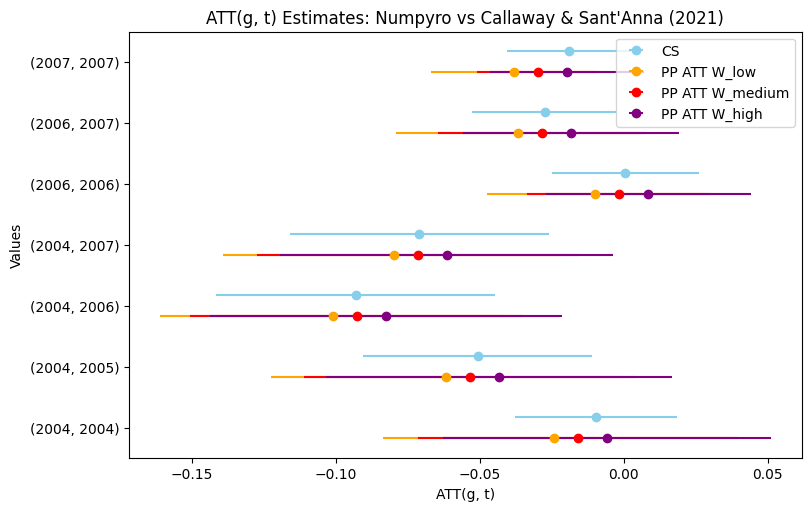

In [40]:
# Filter only cases where ATT(g, t) is not NaN and where Time >= Group
# Note it is also interesting to plot the cases where Time < Group, because the PP
# model indicates, by the large uncertainty, that those cases are not identified 
plot_only_cases_where_ATT_is_defined = True
if plot_only_cases_where_ATT_is_defined:
    df_out_not_nan = df_out[((~df_out['ATT(g, t)'].isna())) & (df_out.index.get_level_values('Time')>=df_out.index.get_level_values('Group'))]
else:
    # Use this to plot only the cases where ATT(g, t) is defined and not NaN
    df_out_not_nan = df_out[((~df_out['ATT(g, t)'].isna()))]

# Setup numerical X positions and bar width
x = np.arange(df_out_not_nan.shape[0])  # Numerical indices [0, 1, 2, 3]
width = 0.35  # Width of each bar

# categories = [f"G{g}, T{t}" for g in idx_g for t in idx_t]
categories = [(idx[0], idx[1]) for idx in df_out_not_nan.index.values]
x = np.arange(len(categories))  # Numerical indices for the categories

fig, ax = plt.subplots(figsize=(8, 5))

i=0
for idx in categories:
        
        g, t = idx
        # Check if the value is not NaN before plotting
        ax.errorbar(
            df_out.loc[(g, t), 'ATT(g, t)'] ,
            x[i] + width / 2,
            xerr=1.96*df_out.loc[(g, t), 'Std. Error'],
            fmt='o',
            color="skyblue",
            label="CS" if i == 0 else ""
        )
        colors = ["orange", "red", "purple"]
        i_offset = 0
        for cat in ['low', 'medium', 'high']:
            ax.errorbar(
                df_out.loc[(g, t), f'ATT_W_{cat}_mean'],
                # x[i] - width / 2- i_offset * 0.3,
                x[i] - width / 2,
                xerr=1.96*df_out.loc[(g, t), f'ATT_W_{cat}_std'],  
                fmt='o',
                color=colors[i_offset],
                label=f"PP ATT W_{cat}" if i == 0 else ""
            )
            i_offset+=1

        i+=1

# Map the numerical X indices back to your String Categories
ax.set_yticks(x)
ax.set_yticklabels(categories)

ax.set_ylabel("Values")
ax.set_title("ATT(g, t) Estimates: Numpyro vs Callaway & Sant'Anna (2021)")
ax.set_xlabel("ATT(g, t)")
ax.legend()

plt.show()

# Possible Next Steps

- Implement frequentist approaches to estimate treatment heterogeneity in the DiD framework

- Extend the model to model the individual and time fixed effects as hierarchical random effects, which will allow for partial pooling and shrinkage of the estimates.

- Explore if the missing overlap is correctly reflected in the posterior distribution uncertainty of the treatment effect estimates.